In [2]:
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd 
import seaborn as sns
from pathlib import Path

In [3]:
original_tsv_path = Path('/Users/thomasbush/Downloads/raw_data/amino_acid_genotypes_to_brightness.tsv')
results_directory = Path('/Users/thomasbush/Downloads/results_protein_rsa')

mutation_df = pd.read_csv(original_tsv_path, sep='\t')
high_effect_dir = results_directory / 'high_effect'
neutral_dir = results_directory / 'neutral'

In [ ]:
# check structural scores:
structure_scores_neutral = pd.read_csv(neutral_dir / 'structure_scores.csv')
structure_scores_high_effect = pd.read_csv(high_effect_dir / 'structure_scores.csv')

Now we can compute a plot showing the distribution of TM-score and teh mutation effect from the two dataset:
- use idx from the structure scores to obtain teh mutation effect in mutation_df["medianBrightness"]

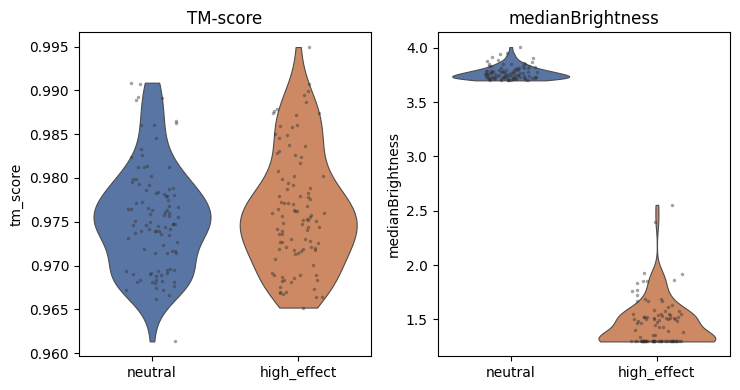

In [13]:
# sequence_idx in structure_scores = 0-based row index in the Sarkisyan TSV (same as seq_XXXXX)
_idx = "sequence_idx" if "sequence_idx" in structure_scores_neutral.columns else "idx"

def attach_brightness(scores: pd.DataFrame, label: str) -> pd.DataFrame:
    out = scores.copy()
    out["cohort"] = label
    out["medianBrightness"] = out[_idx].map(
        lambda i: mutation_df["medianBrightness"].iloc[int(i)]
        if 0 <= int(i) < len(mutation_df)
        else np.nan
    )
    return out

plot_df = pd.concat(
    [
        attach_brightness(structure_scores_neutral, "neutral"),
        attach_brightness(structure_scores_high_effect, "high_effect"),
    ],
    ignore_index=True,
)

# Violin (density) + strip (raw points) per cohort — row 1: TM + brightness; row 2: RMSD + brightness
order = ["neutral", "high_effect"]
colors = ["#4c72b0", "#dd8452"]
panels = [
    [("tm_score", "TM-score"), ("medianBrightness", "medianBrightness")],
    [("rmsd", "RMSD"), ("medianBrightness", "medianBrightness")],
]
fig, axes = plt.subplots(2, 2, figsize=(7.5, 7), sharey=False)
for i, row in enumerate(panels):
    for j, (col, title) in enumerate(row):
        ax = axes[i, j]
        sns.violinplot(
            data=plot_df,
            x="cohort",
            y=col,
            hue="cohort",
            order=order,
            hue_order=order,
            dodge=False,
            ax=ax,
            inner=None,
            cut=0,
            palette=colors,
            linewidth=0.8,
            legend=False,
        )
        sns.stripplot(
            data=plot_df,
            x="cohort",
            y=col,
            order=order,
            ax=ax,
            color="0.2",
            alpha=0.45,
            size=2.5,
            jitter=0.18,
            dodge=False,
        )
        ax.set_title(title)
        ax.set_xlabel("")
fig.tight_layout()
plt.show()

In [ ]:
# Layer-wise cosine divergence: mean ± 1 SD over mutants and diffusion steps
high_effect_divergence = pd.read_csv(high_effect_dir / "high_effect_divergence.csv")
neutral_divergence = pd.read_csv(neutral_dir / "neutral_divergence.csv")
divergence_df = pd.concat([high_effect_divergence, neutral_divergence], ignore_index=True)

plt.figure(figsize=(9, 4))
sns.lineplot(
    data=divergence_df,
    x="layer",
    y="cosine_div",
    hue="class",
    errorbar="sd",
    estimator="mean",
    marker="o",
    markersize=3,
)
plt.xlabel("layer")
plt.ylabel("cosine divergence (mean ± SD)")
plt.tight_layout()
plt.show()

